In [1]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', '--index-url', 
                'https://download.pytorch.org/whl/cu118', '-q'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 71.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 95.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 32.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.2/905.2 MB 934.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.7.1+cu118 which is incompatible.


CompletedProcess(args=['pip', 'install', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu118', '-q'], returncode=0)

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(99)
np.random.seed(99)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [4]:
def soliton(x, t, c, x0):
    arg = (torch.sqrt(torch.tensor(float(c))) / 2.0) * (x - c * t - x0)
    return (c / 2.0) / torch.cosh(arg) ** 2

def make_config(N, d=10.0, T=5.0):
    speeds = [1.5 + 0.5 * (N - 1 - k) for k in range(N)]
    x0s    = [((N - 1) / 2.0 - k) * d  for k in range(N)]
    c_max   = speeds[0]
    x_left  = x0s[-1] - 10.0
    x_right = x0s[0]  + c_max * T + 15.0
    return speeds, x0s, (x_left, x_right)

def n_soliton(x, t, speeds, x0s):
    u = torch.zeros_like(x, dtype=torch.float32)
    for c, x0 in zip(speeds, x0s):
        u = u + soliton(x, t, float(c), float(x0))
    return u

In [5]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [2, 50, 50, 50, 50, 50, 50, 1]
        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        for layer in self.layers:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            z = torch.tanh(layer(z))
        return self.layers[-1](z)

m = PINN()
print(f'params: {sum(p.numel() for p in m.parameters()):,}')

params: 12,951


In [6]:
def derivatives(model, x, t):
    u     = model(x, t)
    u_x   = torch.autograd.grad(u,    x,  grad_outputs=torch.ones_like(u),    create_graph=True)[0]
    u_t   = torch.autograd.grad(u,    t,  grad_outputs=torch.ones_like(u),    create_graph=True)[0]
    u_xx  = torch.autograd.grad(u_x,  x,  grad_outputs=torch.ones_like(u_x),  create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x,  grad_outputs=torch.ones_like(u_xx), create_graph=True)[0]
    return u, u_t, u_x, u_xxx

def pde_loss(model, x, t):
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    res = u_t + 6.0 * u * u_x + u_xxx
    return torch.mean(res ** 2)

def ic_loss(model, x_ic, t_ic, exact_fn):
    u_pred  = model(x_ic, t_ic)
    u_exact = exact_fn(x_ic.squeeze(), t_ic.squeeze()).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)

def bc_loss(model, x_bc, t_bc):
    return torch.mean(model(x_bc, t_bc) ** 2)

def data_loss(model, x_d, t_d, u_d):
    if x_d is None:
        return torch.tensor(0.0, device=next(model.parameters()).device)
    return torch.mean((model(x_d, t_d) - u_d) ** 2)

def total_loss(model, batch, exact_fn):
    x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d = batch
    lp = pde_loss (model, x_pde, t_pde)
    li = ic_loss  (model, x_ic,  t_ic, exact_fn)
    lb = bc_loss  (model, x_bc,  t_bc)
    ld = data_loss(model, x_d,   t_d,  u_d)
    return lp + li + lb + ld, lp, li, lb, ld

In [7]:
def build_data(speeds, x0s, domain, T, n_data, device):
    xl, xr = domain
    width  = xr - xl
    scale  = width / 60.0

    # these stay fixed at N=12 baseline — only n_data changes
    n_pde = int(20000 * scale)
    n_ic  = max(500, int(500 * scale))
    n_bc  = 100

    x_pde = (xl + width * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
    t_pde = (T  *         torch.rand(n_pde, 1)).to(device).requires_grad_(True)

    x_ic  = torch.linspace(xl, xr, n_ic).view(-1, 1).to(device).requires_grad_(True)
    t_ic  = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

    t_bc_v     = torch.linspace(0, T, n_bc).view(-1, 1).to(device)
    x_bc_left  = torch.full((n_bc, 1), float(xl)).to(device).requires_grad_(True)
    x_bc_right = torch.full((n_bc, 1), float(xr)).to(device).requires_grad_(True)
    x_bc = torch.cat([x_bc_left,  x_bc_right], dim=0)
    t_bc = torch.cat([t_bc_v, t_bc_v], dim=0).requires_grad_(True)

    efn = lambda x, t: n_soliton(x, t, speeds, x0s)

    # data points — None if n_data=0
    if n_data == 0:
        x_d, t_d, u_d = None, None, None
    else:
        x_d = (xl + width * torch.rand(n_data, 1)).to(device)
        t_d = (T  *         torch.rand(n_data, 1)).to(device)
        u_d = efn(x_d.squeeze(), t_d.squeeze()).unsqueeze(1).to(device)

    print(f'  PDE: {n_pde:,}  |  Data: {n_data}  |  IC: {n_ic:,}  |  BC: {2*n_bc}')
    return (x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d), efn

In [8]:
def compute_l2(model, exact_fn, domain, T, nx=500, nt=100):
    xl, xr = domain
    x_g = torch.linspace(xl, xr, nx)
    t_g = torch.linspace(0,   T,  nt)
    X, TT = torch.meshgrid(x_g, t_g, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)
    with torch.no_grad():
        u_pred = model(xf, tf).cpu().numpy().reshape(nx, nt)
    u_exact = exact_fn(X.reshape(-1), TT.reshape(-1)).numpy().reshape(nx, nt)
    return float(np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2)))

In [9]:
def train_model(n_data, speeds, x0s, domain, T=5.0, n_adam=15000, n_lbfgs=2000):
    print(f'\n{"="*60}')
    print(f'  N=12  |  n_data={n_data}  |  6x50  |  N=12 baseline settings')
    print(f'{"="*60}')

    batch, exact_fn = build_data(speeds, x0s, domain, T, n_data, device)
    model = PINN().to(device)

    t0 = time.time()

    # Adam
    opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {k: [] for k in ('total', 'pde', 'ic', 'bc', 'data')}

    for i in range(n_adam):
        opt_adam.zero_grad()
        loss, lp, li, lb, ld = total_loss(model, batch, exact_fn)
        loss.backward()
        opt_adam.step()
        hist['total'].append(loss.item())
        hist['pde'].append(lp.item())
        hist['ic'].append(li.item())
        hist['bc'].append(lb.item())
        hist['data'].append(ld.item())
        if i % 1000 == 0:
            print(f'  Adam {i:5d} | Total={loss.item():.6f}  PDE={lp.item():.6f}  IC={li.item():.6f}  Data={ld.item():.6f}')

    t_adam = time.time() - t0
    l2_adam = compute_l2(model, exact_fn, domain, T)
    final_adam_loss = hist['total'][-1]
    print(f'  >> Adam done {t_adam:.1f}s  |  L2={l2_adam*100:.4f}%  |  loss={final_adam_loss:.6f}')

    # L-BFGS
    t1 = time.time()
    opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

    for i in range(n_lbfgs):
        def closure():
            opt_lbfgs.zero_grad()
            loss, *_ = total_loss(model, batch, exact_fn)
            loss.backward()
            return loss
        opt_lbfgs.step(closure)
        if i % 200 == 0:
            loss, *_ = total_loss(model, batch, exact_fn)
            print(f'  LBFGS {i:4d} | Total={loss.item():.8f}')

    t_lbfgs = time.time() - t1
    l2_final = compute_l2(model, exact_fn, domain, T)
    loss_final, *_ = total_loss(model, batch, exact_fn)
    print(f'  >> LBFGS done {t_lbfgs:.1f}s  |  L2={l2_final*100:.4f}%  |  loss={loss_final.item():.8f}')

    return model, exact_fn, hist, {
        'n_data': n_data,
        'l2_adam': l2_adam,
        'l2_final': l2_final,
        'final_adam_loss': final_adam_loss,
        'final_lbfgs_loss': loss_final.item(),
        'time_adam': t_adam,
        'time_lbfgs': t_lbfgs,
    }

In [10]:
T_END = 5.0
speeds, x0s, domain = make_config(N=12, T=T_END)
print(f'N=12 domain: {domain},  width={domain[1]-domain[0]:.1f}')

# the sweep — 0 tests pure PDE+IC+BC with no data at all
n_data_sweep = [0, 100, 200, 500, 1000, 2000]

sweep_results = {}

for n_data in n_data_sweep:
    model, efn, hist, rec = train_model(n_data, speeds, x0s, domain, T=T_END)
    key = f'ndata_{n_data}'
    sweep_results[key] = dict(model=model, exact_fn=efn, hist=hist, **rec)
    torch.save(model.state_dict(), f'checkpoint_N12_ndata{n_data}.pt')
    print(f'  saved: checkpoint_N12_ndata{n_data}.pt\n')

N=12 domain: (-65.0, 105.0),  width=170.0

  N=12  |  n_data=0  |  6x50  |  N=12 baseline settings
  PDE: 56,666  |  Data: 0  |  IC: 1,416  |  BC: 200


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Adam     0 | Total=0.577886  PDE=0.000537  IC=0.512954  Data=0.000000
  Adam  1000 | Total=0.236440  PDE=0.005126  IC=0.231177  Data=0.000000
  Adam  2000 | Total=0.184105  PDE=0.005327  IC=0.178469  Data=0.000000
  Adam  3000 | Total=0.119476  PDE=0.013093  IC=0.106330  Data=0.000000
  Adam  4000 | Total=0.098797  PDE=0.007439  IC=0.091211  Data=0.000000
  Adam  5000 | Total=0.096072  PDE=0.006629  IC=0.089379  Data=0.000000
  Adam  6000 | Total=0.086599  PDE=0.005803  IC=0.080773  Data=0.000000
  Adam  7000 | Total=0.062522  PDE=0.007018  IC=0.055485  Data=0.000000
  Adam  8000 | Total=0.051357  PDE=0.010998  IC=0.040204  Data=0.000000
  Adam  9000 | Total=0.043610  PDE=0.012494  IC=0.031088  Data=0.000000
  Adam 10000 | Total=0.036369  PDE=0.009800  IC=0.026418  Data=0.000000
  Adam 11000 | Total=0.012573  PDE=0.006839  IC=0.005625  Data=0.000000
  Adam 12000 | Total=0.033193  PDE=0.012557  IC=0.020114  Data=0.000000
  Adam 13000 | Total=0.014484  PDE=0.005505  IC=0.008953  Data=0

In [11]:
print(f'\n{"="*65}')
print(f"{'n_data':>8} | {'L2 Adam':>10} | {'L2 Final':>10} | {'Adam loss':>12} | {'LBFGS loss':>12}")
print('-'*65)

for key, r in sweep_results.items():
    print(f"{r['n_data']:>8} | {r['l2_adam']*100:>9.4f}% | {r['l2_final']*100:>9.4f}% | {r['final_adam_loss']:>12.6f} | {r['final_lbfgs_loss']:>12.8f}")

print('='*65)

# print the conclusion hint
l2_0    = sweep_results['ndata_0']['l2_final']
l2_2000 = sweep_results['ndata_2000']['l2_final']
drop    = (l2_0 - l2_2000) / (l2_0 + 1e-10) * 100
print(f'\nn_data=0 -> {l2_0*100:.2f}%,  n_data=2000 -> {l2_2000*100:.2f}%')
print(f'relative drop: {drop:.1f}%')
if l2_2000 < 0.05:
    print('=> data RESCUED N=12 — optimization problem, network has capacity')
elif drop > 50:
    print(f'=> big improvement but still above 5% — partial effect, ambiguous')
else:
    print(f'=> data barely helped — capacity problem, 6x50 cannot represent N=12')


  n_data |    L2 Adam |   L2 Final |    Adam loss |   LBFGS loss
-----------------------------------------------------------------
       0 |   91.2143% |   72.8992% |     0.013999 |   0.01045172
     100 |   76.2526% |   81.2255% |     0.052491 |   0.01764369
     200 |   74.8869% |   74.9669% |     0.035864 |   0.02480596
     500 |   34.5926% |    1.9530% |     0.040103 |   0.00052273
    1000 |   33.9163% |    3.8584% |     0.079226 |   0.00214669
    2000 |   24.6099% |    1.2219% |     0.096752 |   0.00029011

n_data=0 -> 72.90%,  n_data=2000 -> 1.22%
relative drop: 98.3%
=> data RESCUED N=12 — optimization problem, network has capacity


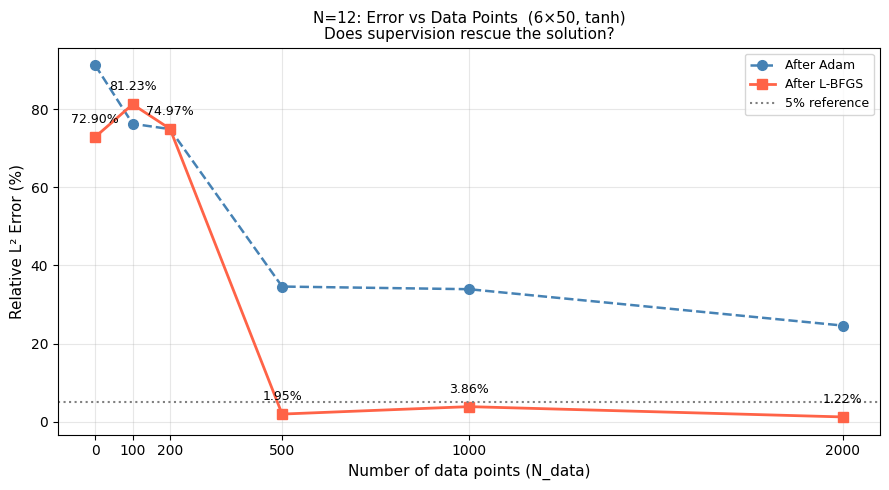

saved: data_saturation_N12.png


In [12]:
n_vals  = [r['n_data']      for r in sweep_results.values()]
l2_adam = [r['l2_adam']*100 for r in sweep_results.values()]
l2_fin  = [r['l2_final']*100 for r in sweep_results.values()]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_vals, l2_adam, 'o--', color='steelblue', linewidth=1.8, markersize=7, label='After Adam')
ax.plot(n_vals, l2_fin,  's-',  color='tomato',    linewidth=2.0, markersize=7, label='After L-BFGS')

for n, e in zip(n_vals, l2_fin):
    ax.annotate(f'{e:.2f}%', (n, e), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.axhline(5.0, color='gray', linestyle=':', linewidth=1.5, label='5% reference')

ax.set_xlabel('Number of data points (N_data)', fontsize=11)
ax.set_ylabel('Relative L² Error (%)', fontsize=11)
ax.set_title('N=12: Error vs Data Points  (6×50, tanh)\nDoes supervision rescue the solution?', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_vals)

plt.tight_layout()
plt.savefig('data_saturation_N12.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: data_saturation_N12.png')